# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Benedictus Ryu Gunawan  | 5054251001 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [21]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [22]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('data/data.csv')
TARGET = "Bankrupt?"
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=[TARGET]), df[TARGET], test_size=0.2, random_state=42)
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

print("Jumlah baris dan kolom:", df_train.shape)
print("Tipe data:")
display(df_train.dtypes)
print("Statistik deskriptif:")
display(df_train.describe())
print("Jumlah missing value:")
display(df_train.isnull().sum())

Jumlah baris dan kolom: (5455, 96)
Tipe data:


 ROA(C) before interest and depreciation before interest    float64
 ROA(A) before interest and % after tax                     float64
 ROA(B) before interest and depreciation after tax          float64
 Operating Gross Margin                                     float64
 Realized Sales Gross Margin                                float64
                                                             ...   
 Degree of Financial Leverage (DFL)                         float64
 Interest Coverage Ratio (Interest expense to EBIT)         float64
 Net Income Flag                                              int64
 Equity to Liability                                        float64
Bankrupt?                                                     int64
Length: 96, dtype: object

Statistik deskriptif:


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Bankrupt?
count,5455.000000,5455.000000,5455.000000,5455.000000,5455.000000,5455.000000,5455.000000,5455.000000,5455.000000,5455.000000,...,5.455000e+03,5455.000000,5455.000000,5455.000000,5455.000000,5455.000000,5455.000000,5455.0,5455.000000,5455.000000
mean,0.505661,0.559095,0.554039,0.607881,0.607862,0.998705,0.797142,0.809030,0.303644,0.781335,...,1.748744e+07,0.623951,0.607879,0.840329,0.280484,0.027622,0.565323,1.0,0.047751,0.030981
std,0.061079,0.065707,0.061805,0.017576,0.017556,0.014538,0.014375,0.015196,0.012474,0.014165,...,3.774208e+08,0.013233,0.017576,0.015865,0.015373,0.017363,0.012292,0.0,0.050763,0.173281
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.133503,0.000000,0.000000,1.0,0.000000,0.000000
25%,0.476698,0.535843,0.527544,0.600455,0.600448,0.998970,0.797386,0.809312,0.303466,0.781567,...,9.023314e-04,0.623638,0.600456,0.840124,0.276952,0.026791,0.565158,1.0,0.024449,0.000000
50%,0.503144,0.560347,0.552599,0.606041,0.606005,0.999023,0.797465,0.809376,0.303525,0.781636,...,2.082324e-03,0.623881,0.606040,0.841201,0.278781,0.026808,0.565254,1.0,0.033776,0.000000
75%,0.535538,0.589730,0.584185,0.613831,0.613734,0.999096,0.797580,0.809470,0.303587,0.781736,...,5.256510e-03,0.624180,0.613832,0.842345,0.281457,0.026913,0.565724,1.0,0.052739,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,0.736985,1.0,1.000000,1.000000


Jumlah missing value:


 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
 Realized Sales Gross Margin                                0
                                                           ..
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Bankrupt?                                                   0
Length: 96, dtype: int64

/tmp/ipykernel_19310/1227144811.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=TARGET, data=df_train, palette='Set2')


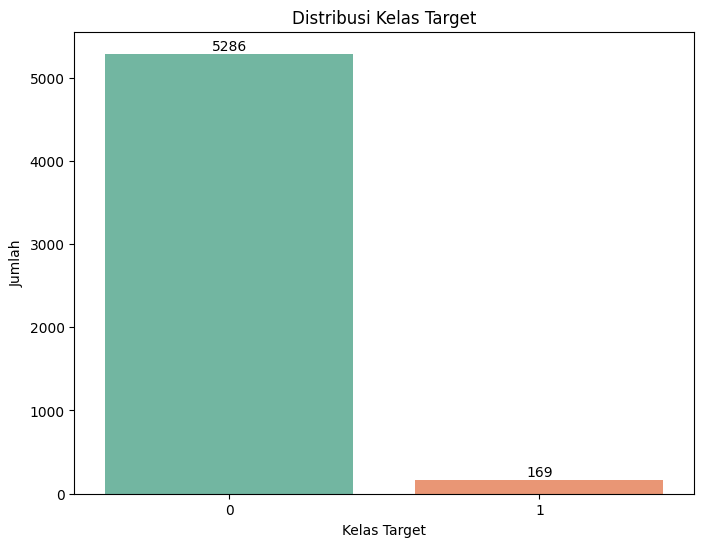

In [23]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

plt.figure(figsize=(8, 6))
sns.countplot(x=TARGET, data=df_train, palette='Set2')
plt.title('Distribusi Kelas Target')

for index, value in enumerate(df_train[TARGET].value_counts()):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.xlabel('Kelas Target')
plt.ylabel('Jumlah')
plt.show()

Text(0.5, 1.0, 'Korelasi Antar Fitur')

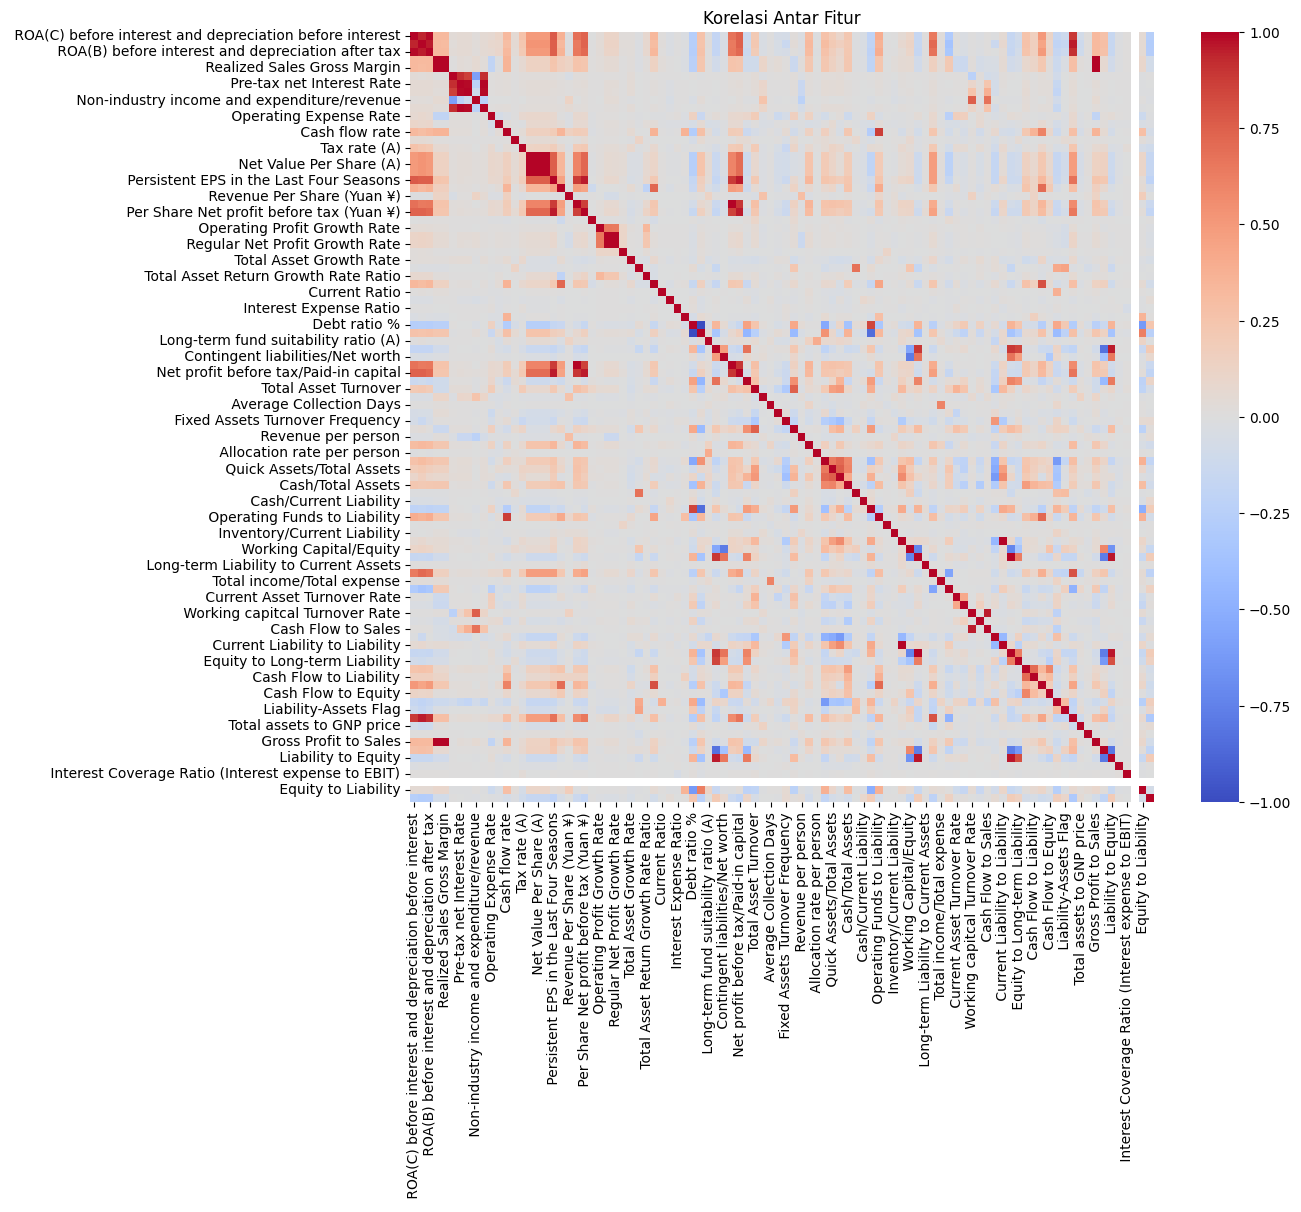

In [24]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.

# Tampilkan korelasi antar fitur dalam bentuk heatmap.
corr_matrix = df_train.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Korelasi Antar Fitur') 


Disini terdapat beberapa fitur yang memiliki hubungan yang sangat erat satu sama lainnya. Disini saya akan mengecek menggunakan VIF

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = df_train.drop(columns=[TARGET])
vif = pd.DataFrame()
vif["Fitur"] = vif_data.columns
vif["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
vif = vif.sort_values(by="VIF", ascending=False)
print("VIF untuk setiap fitur:")
display(vif)

/home/ryz/miniforge3/envs/dsml/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1752: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


VIF untuk setiap fitur:


,Fitur,VIF
76,Current Liability to Liability,1.119713e+11
53,Working Capital to Total Assets,3.325899e+10
36,Debt ratio %,2.970575e+10
63,Current Liabilities/Liability,2.669939e+10
37,Net worth/Assets,2.573964e+10
...,...,...
87,No-credit Interval,1.018621e+00
34,Interest Expense Ratio,1.011709e+00
92,Interest Coverage Ratio (Interest expense to ...,1.008910e+00
91,Degree of Financial Leverage (DFL),1.005557e+00


/home/ryz/miniforge3/envs/dsml/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Hasil UMAP untuk fitur dengan VIF tinggi:


Text(0, 0.5, 'UMAP2')

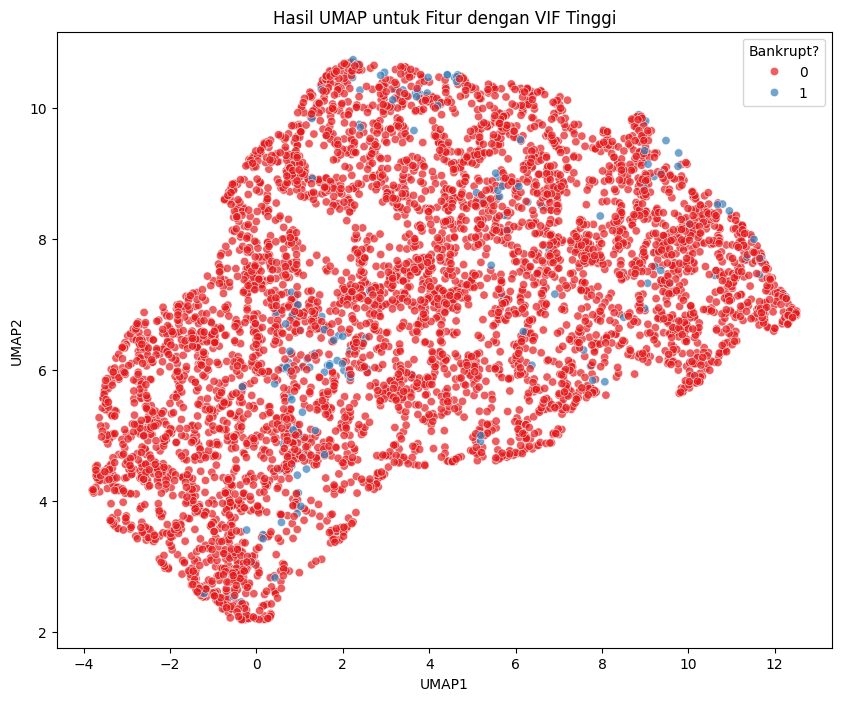

In [26]:
from umap import UMAP

high_vif_features = vif[vif["VIF"] > 10]["Fitur"].tolist()
model = UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
X_umap = model.fit_transform(df_train[high_vif_features])
df_UMAP = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'])
# Tambahkan kolom target ke DataFrame UMAP
df_UMAP[TARGET] = df_train[TARGET].values

print("Hasil UMAP untuk fitur dengan VIF tinggi:")
plt.figure(figsize=(10, 8))
sns.scatterplot(x='UMAP1', y='UMAP2', hue=TARGET, data=df_UMAP, palette='Set1', alpha=0.7)
plt.title('Hasil UMAP untuk Fitur dengan VIF Tinggi')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')


# 2. Preprocessing

<Axes: >

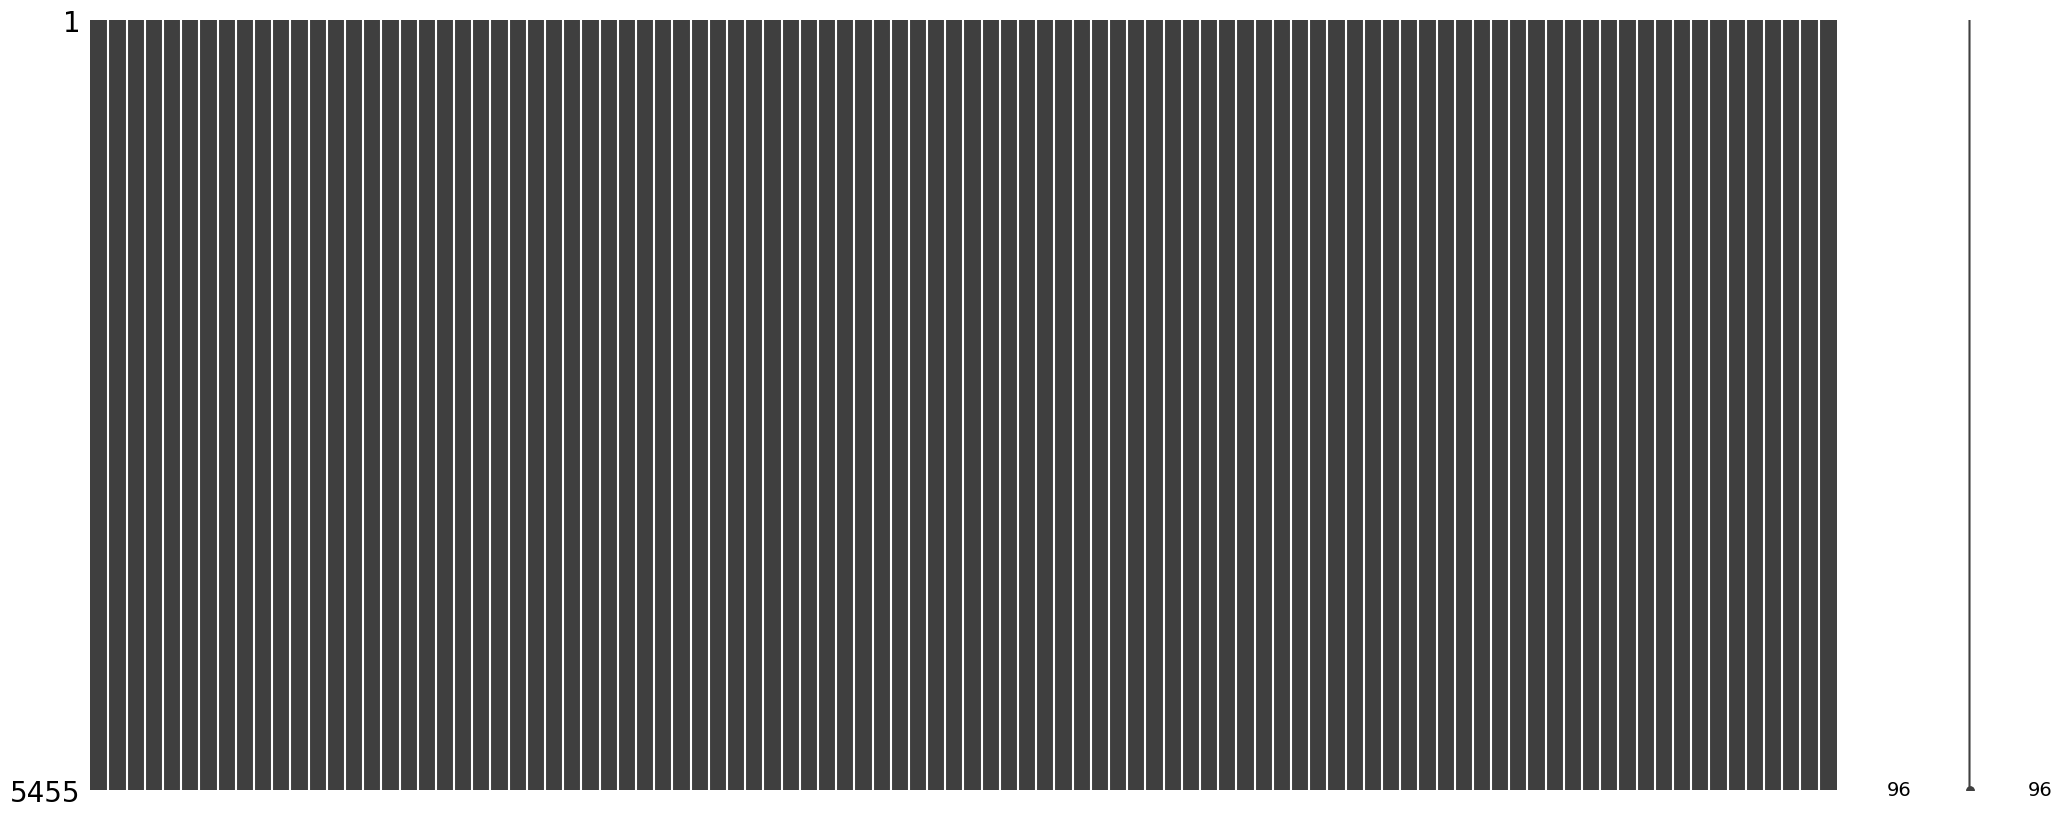

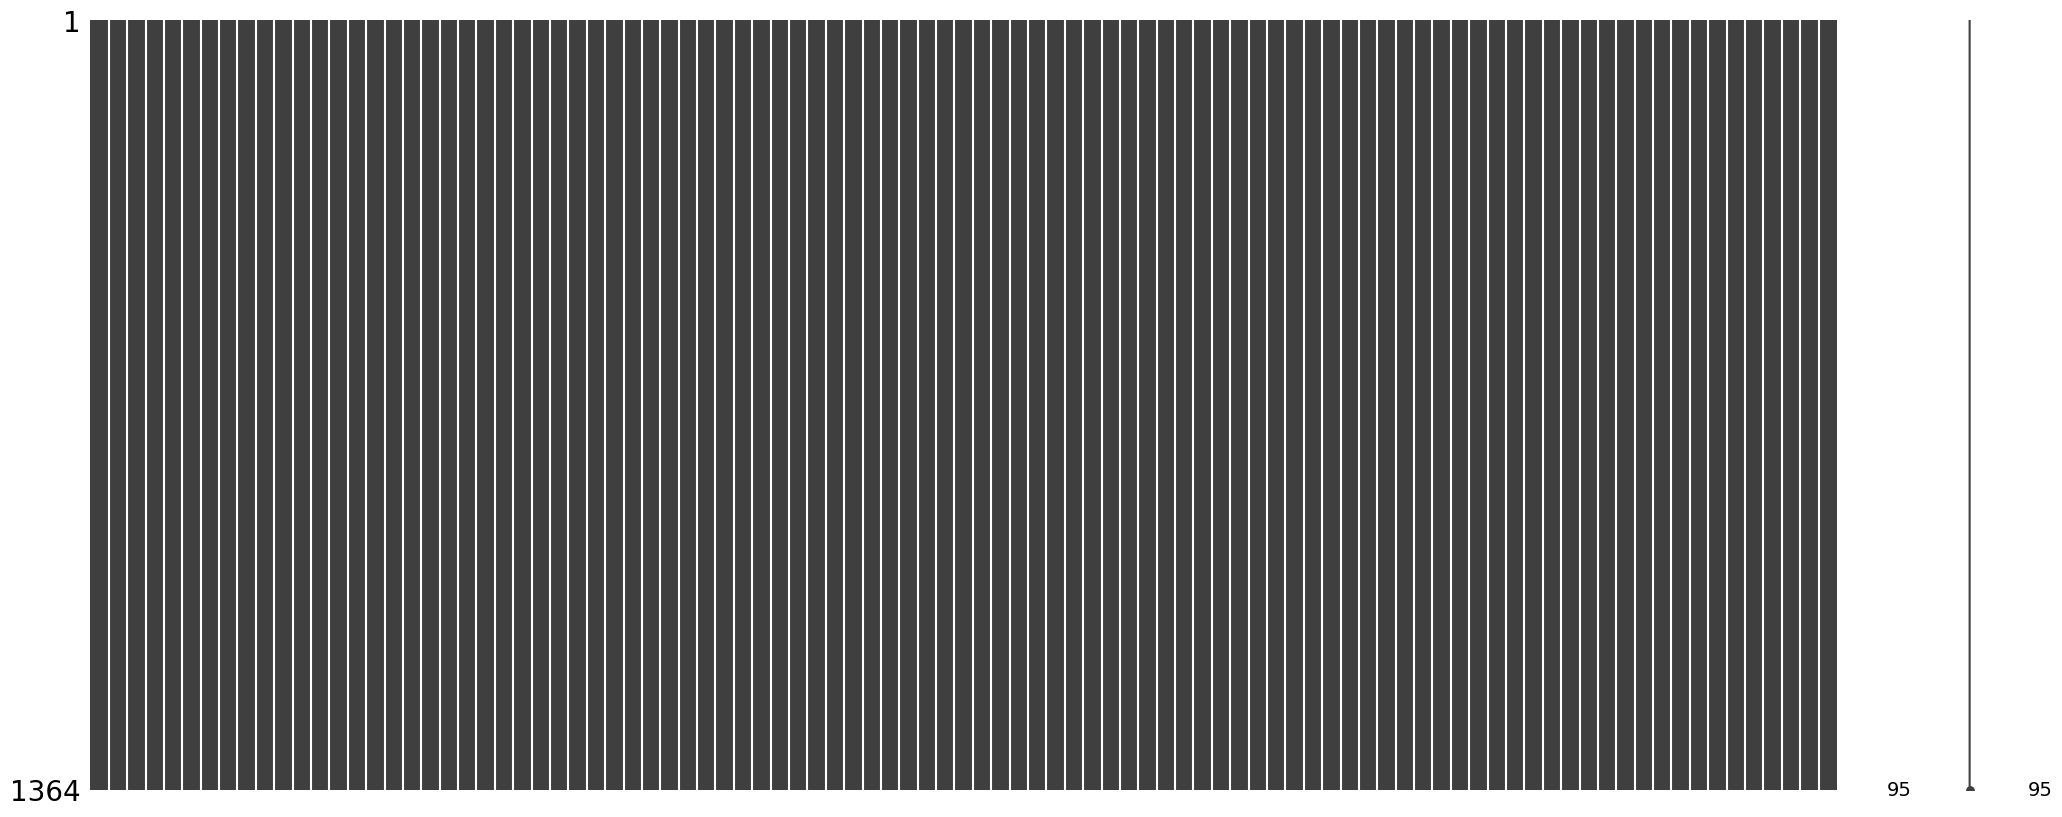

In [27]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

import missingno as msno

msno.matrix(df_train)
msno.matrix(X_test)

In [28]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5455 entries, 3759 to 860
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0    ROA(C) before interest and depreciation before interest  5455 non-null   float64
 1    ROA(A) before interest and % after tax                   5455 non-null   float64
 2    ROA(B) before interest and depreciation after tax        5455 non-null   float64
 3    Operating Gross Margin                                   5455 non-null   float64
 4    Realized Sales Gross Margin                              5455 non-null   float64
 5    Operating Profit Rate                                    5455 non-null   float64
 6    Pre-tax net Interest Rate                                5455 non-null   float64
 7    After-tax net Interest Rate                              5455 non-null   float64
 8    Non-industry income 

In [29]:
cat_cols = df_train.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols

[]

**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [30]:
model_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
model_gini.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [31]:
y_pred_gini = model_gini.predict(X_test)

## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [32]:
model_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_entropy.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
y_pred_entropy = model_entropy.predict(X_test)

## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [34]:
max_depths = [1, 2, 3, 5, 10, None]
models = {}
for d in max_depths:
    clf = DecisionTreeClassifier(criterion="gini", max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    models[d] = clf

In [35]:
train_acc = [models[d].score(X_train, y_train) for d in max_depths]
test_acc = [models[d].score(X_test, y_test) for d in max_depths]

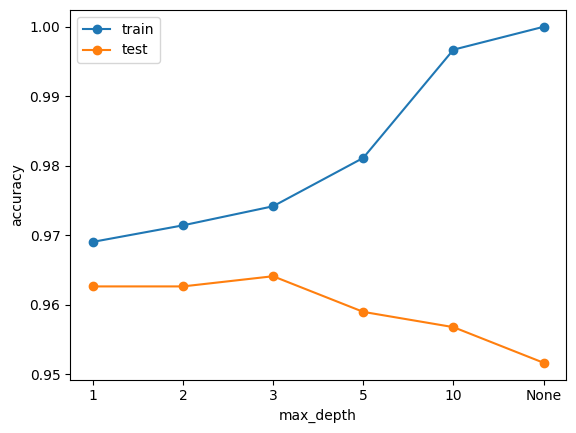

In [36]:
x_labels = [str(d) for d in max_depths]
plt.figure()
plt.plot(x_labels, train_acc, marker="o", label="train")
plt.plot(x_labels, test_acc, marker="o", label="test")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.legend()
plt.show()

# 4. Evaluasi Model

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
results = pd.DataFrame({
    "model": ["gini", "entropy"],
    "accuracy": [accuracy_score(y_test, y_pred_gini), accuracy_score(y_test, y_pred_entropy)],
    "precision": [precision_score(y_test, y_pred_gini, zero_division=0), precision_score(y_test, y_pred_entropy, zero_division=0)],
    "recall": [recall_score(y_test, y_pred_gini, zero_division=0), recall_score(y_test, y_pred_entropy, zero_division=0)],
    "f1": [f1_score(y_test, y_pred_gini, zero_division=0), f1_score(y_test, y_pred_entropy, zero_division=0)]
})
results

,model,accuracy,precision,recall,f1
0,gini,0.951613,0.346939,0.333333,0.340000
1,entropy,0.947214,0.294118,0.294118,0.294118


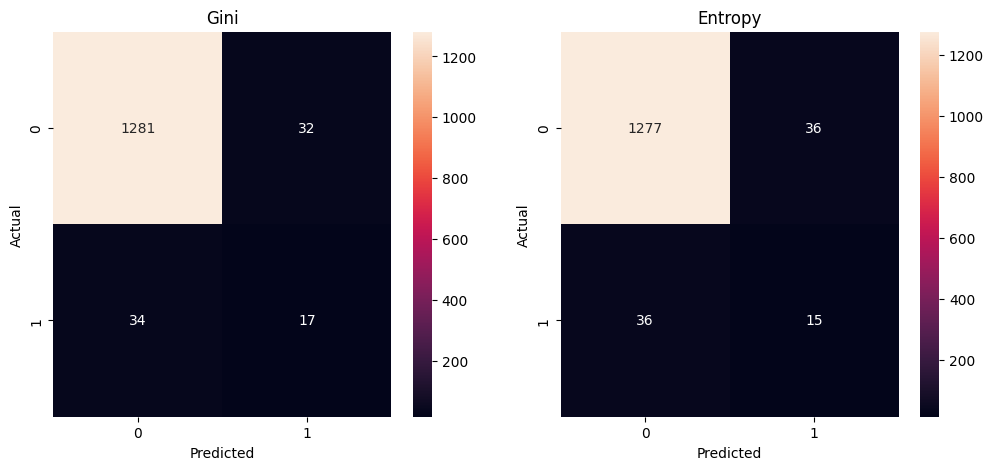

In [38]:
from sklearn.metrics import confusion_matrix
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_gini), annot=True, fmt="d", ax=ax[0])
ax[0].set_title("Gini")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
sns.heatmap(confusion_matrix(y_test, y_pred_entropy), annot=True, fmt="d", ax=ax[1])
ax[1].set_title("Entropy")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
plt.show()

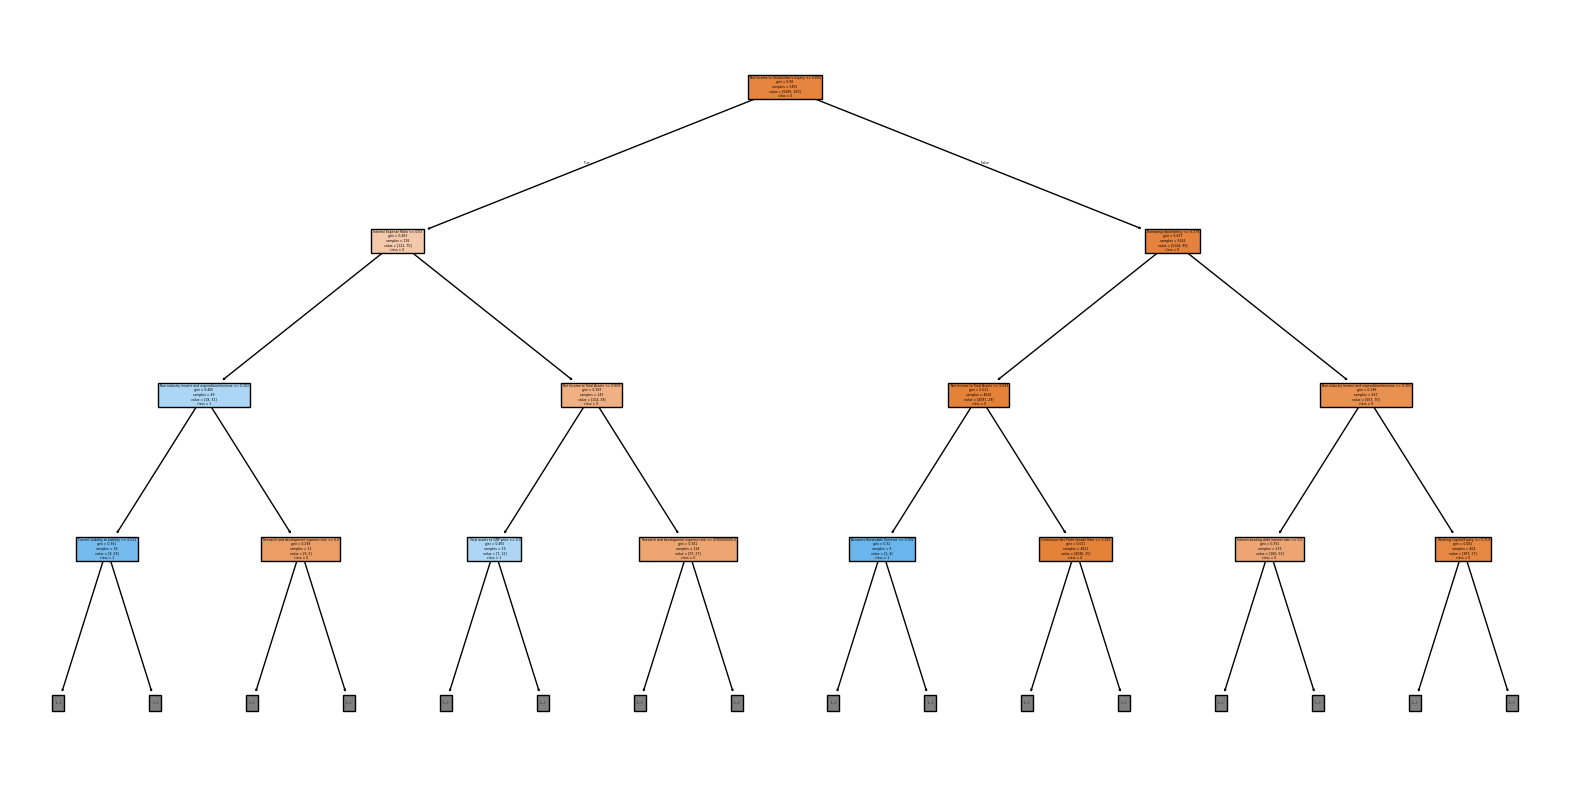

In [39]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(model_gini, max_depth=3, feature_names=X_train.columns.tolist(), class_names=["0", "1"], filled=True)
plt.show()

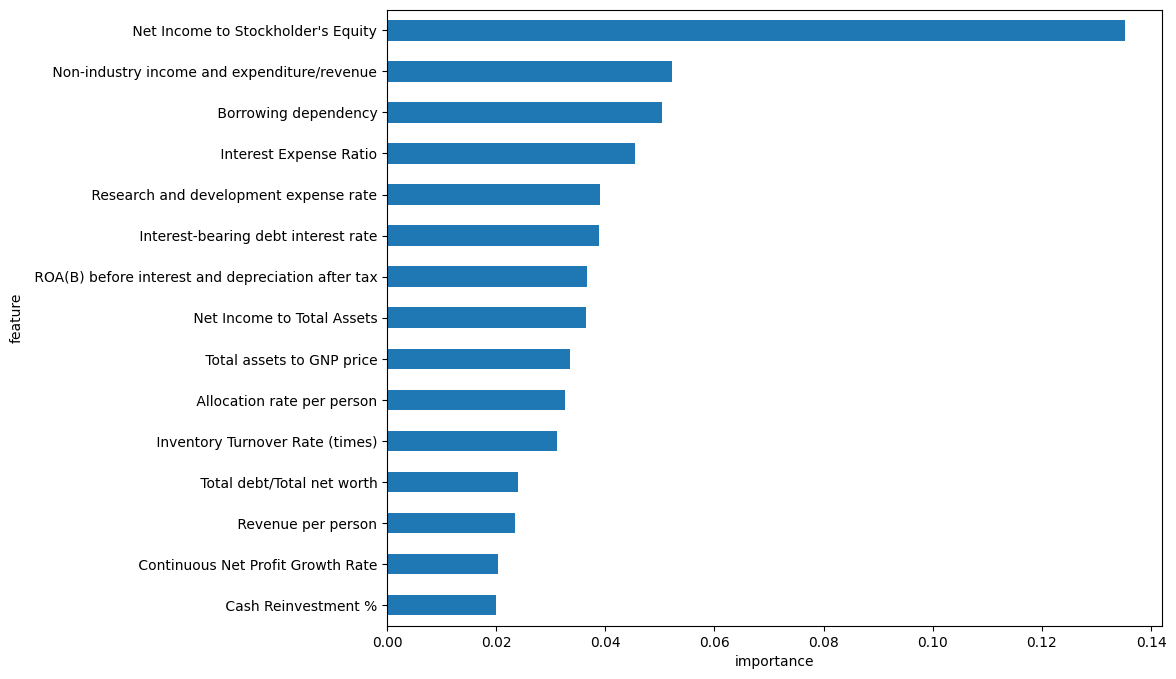

In [40]:
importances = pd.Series(model_gini.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(15)
plt.figure(figsize=(10, 8))
importances.plot(kind="barh")
plt.xlabel("importance")
plt.ylabel("feature")
plt.show()

# 4b. Perbandingan Preprocessing vs Baseline

Baseline adalah DecisionTree Gini semua fitur dari sel 3.1. Semua varian memakai split dan model yang sama, preprocessing hanya di-fit pada train lalu diaplikasikan ke test. UMAP hanya memakai fitur VIF tinggi.

## 4b.1 Baseline

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
baseline_pred = y_pred_gini
baseline_scores = {
    "accuracy": accuracy_score(y_test, baseline_pred),
    "precision": precision_score(y_test, baseline_pred, zero_division=0),
    "recall": recall_score(y_test, baseline_pred, zero_division=0),
    "f1": f1_score(y_test, baseline_pred, zero_division=0)
}
baseline_scores

{'accuracy': 0.9516129032258065,
 'precision': 0.3469387755102041,
 'recall': 0.3333333333333333,
 'f1': 0.34}

## 4b.2 UMAP khusus fitur VIF tinggi

In [42]:
from sklearn.preprocessing import StandardScaler
from umap import UMAP
high_vif_features = vif[vif["VIF"] > 10]["Fitur"].tolist()
scaler_umap = StandardScaler()
X_train_vif = scaler_umap.fit_transform(X_train[high_vif_features])
X_test_vif = scaler_umap.transform(X_test[high_vif_features])
umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_train_umap = umap_model.fit_transform(X_train_vif)
X_test_umap = umap_model.transform(X_test_vif)
umap_clf = DecisionTreeClassifier(criterion="gini", random_state=42)
umap_clf.fit(X_train_umap, y_train)
y_pred_umap = umap_clf.predict(X_test_umap)
umap_scores = {
    "accuracy": accuracy_score(y_test, y_pred_umap),
    "precision": precision_score(y_test, y_pred_umap, zero_division=0),
    "recall": recall_score(y_test, y_pred_umap, zero_division=0),
    "f1": f1_score(y_test, y_pred_umap, zero_division=0)
}
umap_scores

/home/ryz/miniforge3/envs/dsml/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'accuracy': 0.9376832844574781,
 'precision': 0.13043478260869565,
 'recall': 0.11764705882352941,
 'f1': 0.12371134020618557}

## 4b.3 RFE

In [43]:
from sklearn.feature_selection import RFE
rfe_selector = RFE(estimator=DecisionTreeClassifier(criterion="gini", random_state=42), n_features_to_select=20)
X_train_rfe = rfe_selector.fit_transform(X_train, y_train)
X_test_rfe = rfe_selector.transform(X_test)
rfe_clf = DecisionTreeClassifier(criterion="gini", random_state=42)
rfe_clf.fit(X_train_rfe, y_train)
y_pred_rfe = rfe_clf.predict(X_test_rfe)
rfe_scores = {
    "accuracy": accuracy_score(y_test, y_pred_rfe),
    "precision": precision_score(y_test, y_pred_rfe, zero_division=0),
    "recall": recall_score(y_test, y_pred_rfe, zero_division=0),
    "f1": f1_score(y_test, y_pred_rfe, zero_division=0)
}
rfe_scores

{'accuracy': 0.9464809384164223,
 'precision': 0.28846153846153844,
 'recall': 0.29411764705882354,
 'f1': 0.2912621359223301}

## 4b.4 SelectKBest

In [44]:
from sklearn.feature_selection import SelectKBest, f_classif
skb_selector = SelectKBest(score_func=f_classif, k=20)
X_train_skb = skb_selector.fit_transform(X_train, y_train)
X_test_skb = skb_selector.transform(X_test)
skb_clf = DecisionTreeClassifier(criterion="gini", random_state=42)
skb_clf.fit(X_train_skb, y_train)
y_pred_skb = skb_clf.predict(X_test_skb)
skb_scores = {
    "accuracy": accuracy_score(y_test, y_pred_skb),
    "precision": precision_score(y_test, y_pred_skb, zero_division=0),
    "recall": recall_score(y_test, y_pred_skb, zero_division=0),
    "f1": f1_score(y_test, y_pred_skb, zero_division=0)
}
skb_scores

/home/ryz/miniforge3/envs/dsml/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [93] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/ryz/miniforge3/envs/dsml/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


{'accuracy': 0.9523460410557185,
 'precision': 0.3157894736842105,
 'recall': 0.23529411764705882,
 'f1': 0.2696629213483146}

## 4b.5 Rekap vs Baseline

In [45]:
prep_results = pd.DataFrame({
    "method": ["Baseline", "UMAP-VIF", "RFE", "SelectKBest"],
    "accuracy": [baseline_scores["accuracy"], umap_scores["accuracy"], rfe_scores["accuracy"], skb_scores["accuracy"]],
    "precision": [baseline_scores["precision"], umap_scores["precision"], rfe_scores["precision"], skb_scores["precision"]],
    "recall": [baseline_scores["recall"], umap_scores["recall"], rfe_scores["recall"], skb_scores["recall"]],
    "f1": [baseline_scores["f1"], umap_scores["f1"], rfe_scores["f1"], skb_scores["f1"]]
})
delta_vs_baseline = prep_results.set_index("method")[["accuracy", "precision", "recall", "f1"]].subtract(prep_results.set_index("method").loc["Baseline"])
display(prep_results)
display(delta_vs_baseline)

,method,accuracy,precision,recall,f1
0,Baseline,0.951613,0.346939,0.333333,0.340000
1,UMAP-VIF,0.937683,0.130435,0.117647,0.123711
2,RFE,0.946481,0.288462,0.294118,0.291262
3,SelectKBest,0.952346,0.315789,0.235294,0.269663


,accuracy,precision,recall,f1
method,,,,
Baseline,0.000000,0.000000,0.000000,0.000000
UMAP-VIF,-0.013930,-0.216504,-0.215686,-0.216289
RFE,-0.005132,-0.058477,-0.039216,-0.048738
SelectKBest,0.000733,-0.031149,-0.098039,-0.070337


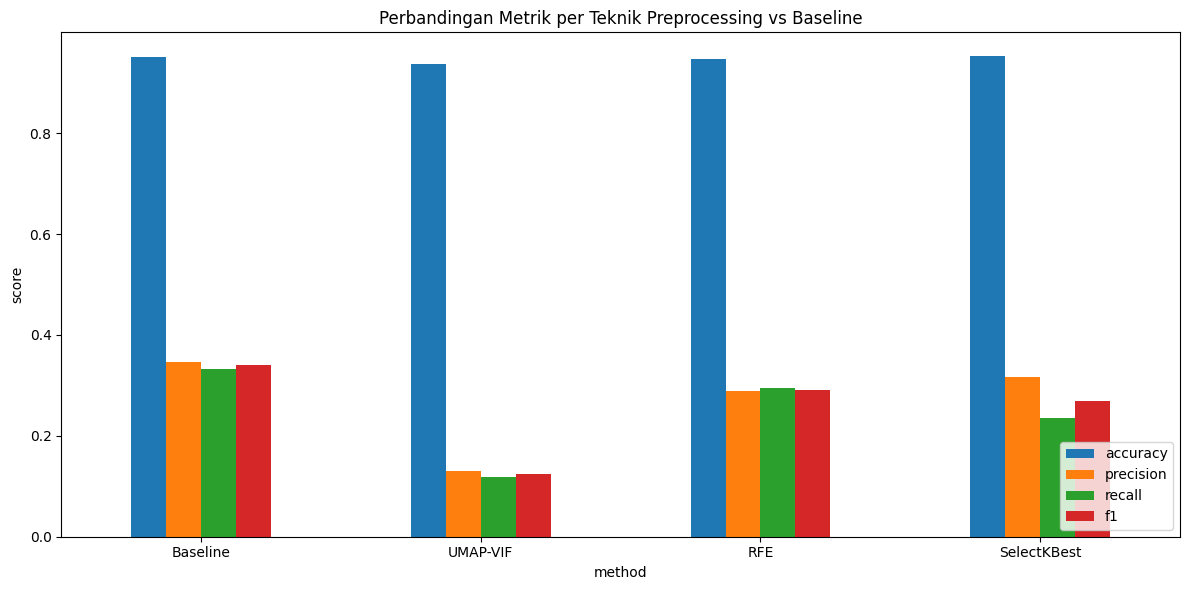

In [46]:
plot_df = prep_results.set_index("method")[["accuracy", "precision", "recall", "f1"]]
ax = plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Perbandingan Metrik per Teknik Preprocessing vs Baseline")
plt.xlabel("method")
plt.ylabel("score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

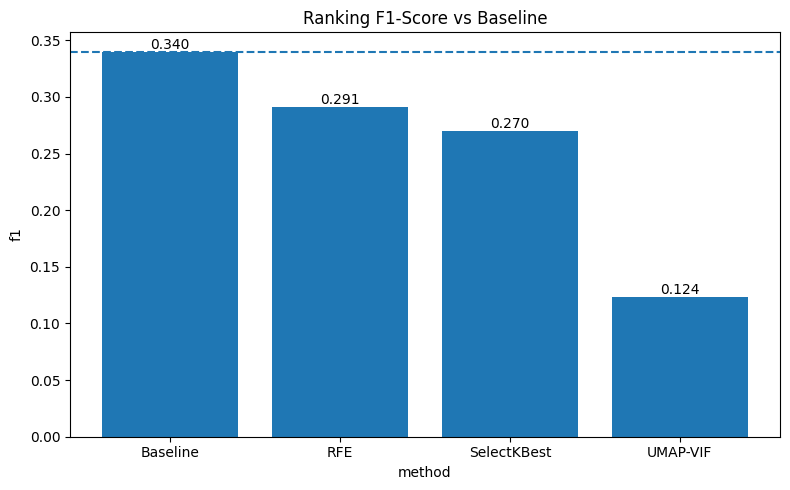

In [47]:
f1_sorted = prep_results.sort_values("f1", ascending=False)
plt.figure(figsize=(8, 5))
plt.bar(f1_sorted["method"], f1_sorted["f1"])
plt.axhline(baseline_scores["f1"], linestyle="--")
plt.title("Ranking F1-Score vs Baseline")
plt.xlabel("method")
plt.ylabel("f1")
for i, v in enumerate(f1_sorted["f1"]):
    plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

# 5. Analisis

### 5.1 Gini vs Entropy

Hasil test set identik pada accuracy 0.953 untuk kedua kriteria, tetapi berbeda pada kelas minoritas. Gini memperoleh precision 0.362, recall 0.333, F1 0.347. Entropy memperoleh precision 0.341, recall 0.275, F1 0.304. Selisih F1 sekitar 0.043.

Confusion matrix Gini: TN 1283, FP 30, FN 34, TP 17. Entropy: TN 1286, FP 27, FN 37, TP 14. Gini menemukan 3 kasus bangkrut lebih banyak dengan tambahan 3 false positive.

Perbedaan tidak besar karena kedua kriteria mengukur impurity dengan cara mirip pada data yang sangat imbalance. Mayoritas sampel adalah kelas 0 sekitar 96.3 persen pada test, sehingga split awal hampir sama. Gini sedikit lebih baik di sini karena cenderung memilih partisi besar yang stabil, sedangkan entropy dengan log lebih sensitif pada perubahan probabilitas kecil dan menghasilkan pohon lebih ramping. Pada eksperimen ini kedalaman aktual Gini 15 dengan 118 leaves, Entropy 14 dengan 95 leaves.

Accuracy 0.95 menipu karena model yang selalu menebak tidak bangkrut pun sudah mendapat sekitar 0.963. Metrik yang jujur adalah precision, recall, dan F1 pada kelas bangkrut yang semuanya masih rendah di kisaran 0.27 sampai 0.36.

### 5.2 Pengaruh max_depth dan overfitting

Eksperimen memakai kriteria Gini dengan max_depth 1, 2, 3, 5, 10, None. Akurasi train naik monoton dari 0.969 pada depth 1 menuju 1.000 pada depth None. Akurasi test naik dari 0.963 pada depth 1 ke puncak 0.964 pada depth 3, lalu turun ke 0.959 pada depth 5, 0.957 pada depth 10, dan 0.953 pada tanpa batas.

Ciri overfitting jelas setelah depth 3 sampai 5. Train terus naik sedangkan test stagnan lalu menurun, sehingga gap train-test melebar dari sekitar 0.01 pada depth 3 menjadi sekitar 0.047 pada tanpa batas. Depth 1 dan 2 underfit karena pohon terlalu sederhana untuk menangkap pola profitabilitas dan utang. Depth 3 adalah titik seimbang untuk accuracy pada grafik. Pohon tanpa batas menghafal train sampai 100 persen tetapi generalisasi memburuk.

### 5.3 Feature importance

Model Gini menempatkan Net Income to Stockholder Equity pada urutan pertama dengan importance 0.135, jauh di atas fitur kedua Non-industry income and expenditure per revenue 0.052. Berikutnya Borrowing dependency 0.043, Net Income to Total Assets 0.042, Research and development expense rate 0.039, Interest-bearing debt interest rate 0.039, Interest Expense Ratio 0.038, dan ROA B 0.037.

Pola ini masuk akal. Kebangkrutan pada dataset ini paling dipisahkan oleh profitabilitas terhadap ekuitas dan aset, ditambah beban utang dan bunga. Visualisasi plot_tree depth 3 juga menunjukkan split awal memakai fitur sejenis, sehingga konsisten dengan importance global.

### 5.4 Preprocessing vs baseline

Baseline tanpa preprocessing menang pada semua metrik. UMAP khusus 42 fitur VIF tinggi dengan Scaler plus UMAP 2 komponen turun paling jauh: accuracy 0.949, F1 0.205, delta F1 minus 0.142 terhadap baseline. RFE 20 fitur mendapat accuracy 0.948, F1 0.268, delta minus 0.079. SelectKBest 20 fitur mendapat accuracy 0.952, F1 0.270, delta minus 0.077.

UMAP 2D cocok untuk visualisasi seperti pada sel 8, tetapi merugikan Decision Tree karena mengubah fitur asli yang punya threshold jelas menjadi koordinat manifold yang padat dan sulit di-split. RFE dan SelectKBest membuang sekitar 75 fitur sehingga interaksi antar rasio keuangan yang dipakai pohon dalam hilang. Semua preprocessing sudah di-fit hanya pada train lalu ditransform ke test, jadi penurunan ini bukan leakage, melainkan kehilangan informasi. Kesimpulan praktis: untuk Decision Tree pada data ini, pertahankan fitur asli dan atasi multikolinearitas lewat pembatasan depth atau pruning, bukan lewat reduksi dimensi agresif.

# 6. Kesimpulan dan Saran

### Kesimpulan

1. Gini sedikit lebih baik dari Entropy pada F1 kelas bangkrut 0.347 vs 0.304, dengan accuracy sama 0.953. Perbedaan kecil dan wajar karena keduanya mengukur impurity secara mirip pada data imbalance 3.2 persen.
2. Overfitting muncul setelah max_depth 3 sampai 5. Train menuju 1.000 sedangkan test turun dari puncak 0.964 ke 0.953. Depth 3 adalah kompromi terbaik untuk accuracy pada grafik.
3. Fitur terpenting adalah Net Income to Stockholder Equity 0.135, diikuti indikator non-industry income, borrowing dependency, net income to assets, dan beban bunga. Fokus pada profitabilitas dan struktur utang.
4. Semua varian preprocessing kalah dari baseline. UMAP-VIF turun paling besar dengan delta F1 minus 0.142, RFE minus 0.079, SelectKBest minus 0.077. Reduksi dimensi menghilangkan threshold asli yang dibutuhkan tree.

### Saran

1. Perbaiki evaluasi imbalance: pakai stratified split, laporkan precision recall F1 dan PR-AUC, tuning threshold, coba class_weight balanced atau SMOTE, dan validasi silang stratified.
2. Lanjut pruning terstruktur: coba ccp_alpha pruning path, min_samples_leaf 5 sampai 20, dan min_samples_split untuk menekan leaves dari 118 ke kisaran belasan tanpa mengorbankan recall.
3. Tangani fitur bermasalah: hapus fitur konstan seperti Net Income Flag, gabung atau seleksi fitur dengan korelasi sangat tinggi selain VIF, lalu uji RFECV dan SelectKBest dengan variasi k memakai F1 sebagai skor.
4. Bandingkan model yang lebih tahan imbalance seperti Random Forest, Gradient Boosting, atau Logistic Regression ber regularisasi sebagai pembanding yang adil dengan Decision Tree tunggal.